In [1]:
import os
import re

import mne
import numpy as np
import pandas as pd
from autoreject import AutoReject
from pyprep.find_noisy_channels import NoisyChannels


In [2]:
# Se seleccionan solamente los eventos de los bloques 3,4,6 y 7 correspondientes a 
# estímulos cuyas respuestas fueron correctas

def extraerCorrectas(eventos):
    pos=[]
    correctas=[]
    i=0
    j=0
    for i in range(len(eventos)):
        if eventos[i][2] == 12 and eventos[i+1][2]==108:
            pos.append(i)
        elif eventos[i][2] == 13 and eventos[i+1][2]==109:
            pos.append(i)
        elif eventos[i][2] == 14 and eventos[i+1][2]==110:
            pos.append(i)
        elif eventos[i][2] == 15 and eventos[i+1][2]==111:
            pos.append(i)
        elif eventos[i][2] == 16 and eventos[i+1][2]==112:
            pos.append(i)
        elif eventos[i][2] == 17 and eventos[i+1][2]==113:
            pos.append(i)
        elif eventos[i][2] == 18 and eventos[i+1][2]==114:
            pos.append(i)
        elif eventos[i][2] == 19 and eventos[i+1][2]==115:
            pos.append(i)
        elif eventos[i][2] == 24 and eventos[i+1][2]==120:
            pos.append(i)
        elif eventos[i][2] == 25 and eventos[i+1][2]==121:
            pos.append(i)
        elif eventos[i][2] == 26 and eventos[i+1][2]==122:
            pos.append(i)
        elif eventos[i][2] == 27 and eventos[i+1][2]==123:
            pos.append(i)    
        elif eventos[i][2] == 28 and eventos[i+1][2]==124:
            pos.append(i)
        elif eventos[i][2] == 29 and eventos[i+1][2]==125:
            pos.append(i)
        elif eventos[i][2] == 30 and eventos[i+1][2]==126:
            pos.append(i)
        elif eventos[i][2] == 31 and eventos[i+1][2]==127:
            pos.append(i)
    for j in range(len(pos)):
        x=int(pos[j])
        y=eventos[x]
        correctas.append(y)
    return correctas

In [ ]:
# Primero eliminación e interpolación de canales malos, luego referenciación REST, 
# luego ICA, luego epoching, luego remoción épocas malas

def Preprocesamiento_REST_ICA_epoch(
    raw,
    decim=8,
    montage='biosemi64',
    h_freq=30,
    l_freq=0.2,
    tmax=2.0,
    threshold=0.5,
):
    # Montaje
    raw.set_montage(
        montage=mne.channels.make_standard_montage(kind=montage), 
        match_case=False
        )
    
    # Preparación de referenciación REST - modelo de cabeza
    raw.del_proj()
    sphere = mne.make_sphere_model(
        'auto', 
        'auto', 
        raw.info
        )
    
    src = mne.setup_volume_source_space(
        sphere=sphere, 
        exclude=30., 
        pos=5.
        )
    
    forward = mne.make_forward_solution(
        raw.info, 
        trans=None, 
        src=src, 
        bem=sphere
        )
    
    # Detección de canales ruidosos
    raw = raw.filter(
        l_freq=l_freq, 
        h_freq=None
        )
       
    NC = NoisyChannels(
        raw, 
        do_detrend=True
        )
    
    NC.find_all_bads(ransac=False)
    bad_channels = NC.get_bads()
    
    # Interpolación de canales ruidosos
    raw.info["bads"] = NC.get_bads()
    raw.interpolate_bads(reset_bads=True, verbose=False)
    
    # Referenciación REST
    raw.set_eeg_reference(
        ref_channels='REST', 
        projection=False, 
        ch_type='auto', 
        forward=forward
        )
            
    # Cálculo de componentes independientes
    ica = mne.preprocessing.ICA(
        n_components=None, 
        random_state=1, 
        method='fastica'
        )
    
    ica.fit(raw)
 
    # Detección de componentes oculares
    eog_indices, ___ = ica.find_bads_eog(raw, ch_name='FPZ')
     
    # Detección de componentes musculares
    muscle_indices, ___ = ica.find_bads_muscle(raw, threshold=threshold)
    
    # Eliminación de componentes
    ica.exclude = eog_indices + muscle_indices
    ica_bad_components = list(ica.exclude)
    ica.apply(raw, exclude=ica.exclude)
        
    # Epoching, selección de épocas de interés y submuestreo
    events = mne.find_events(raw, stim_channel='Status')
    event_id = [12, 13, 14, 15, 16, 17, 18, 19, 24, 25, 26, 27, 28, 29, 30, 31]

    # Aplicar un filtro de paso bajo antes de la decimación para evitar aliasing
    raw.filter(l_freq=None, h_freq=h_freq)

    # Extraer solo las épocas de los eventos de interés
    epochs= mne.Epochs(
        raw, 
        events=events, 
        event_id=event_id, 
        tmin=-0.2, tmax=tmax, 
        baseline=(None,0), 
        picks=['eeg'], 
        preload=True, 
        decim=decim
        )
    
    # Reparación y eliminación de épocas malas
    ar = AutoReject(verbose = False, random_state = 1)
    ar.fit(epochs)
    epochs_clean, reject_log = ar.transform(epochs, return_log=True)
    bad_epochs = np.sum(reject_log.bad_epochs)
    
    print('Canales ruidosos: ',bad_channels)
    print('Componentes oculares: ',eog_indices)
    print('Componentes musculares: ',muscle_indices)
    print('Épocas rechazadas: ', bad_epochs)
        
    return epochs_clean, bad_channels, ica_bad_components, bad_epochs


# Prueba con pocos sujetos

In [4]:
from pathlib import Path

DATA_DIR = Path().resolve().parent / 'data' / 'eeg-raw'
file_name = '21101_IAT2.edf'
file_path = DATA_DIR / file_name
 
montage = mne.channels.make_standard_montage('biosemi64')
raw = mne.io.read_raw_edf(
    file_path, 
    preload=True
    )

epochs, bad_channels, ica_bad_components, bad_epochs = Preprocesamiento_REST_ICA_epoch(
    raw, 
    threshold=0.9
    )

Extracting EDF parameters from C:\Users\Usuario\repos\iat-eeg\data\eeg-raw\21101_IAT2.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1251327  =      0.000 ...   611.000 secs...
Fitted sphere radius:         95.0 mm
Origin head coordinates:      -0.0 0.0 40.1 mm
Origin device coordinates:    -0.0 0.0 40.1 mm

Equiv. model fitting -> RV = 0.00347455 %%
mu1 = 0.944856    lambda1 = 0.136823
mu2 = 0.667779    lambda2 = 0.683693
mu3 = -0.294888    lambda3 = -0.0101468
Set up EEG sphere model with scalp radius    95.0 mm

Sphere                : origin at (-0.0 0.0 40.1) mm
              radius  : 85.5 mm
grid                  : 5.0 mm
mindist               : 5.0 mm
Exclude               : 30.0 mm

Setting up the sphere...
Surface CM = (  -0.0    0.0   40.1) mm
Surface fits inside a sphere with radius   85.5 mm
Surface extent:
    x =  -85.5 ...   85.5 mm
    y =  -85.5 ...   85.5 mm
    z =  -45.4 ...  125.6 mm
Grid extent:
    x =  -90.0 ...   90.0 mm


Need more than one channel to make topography for eeg. Disabling interactivity.


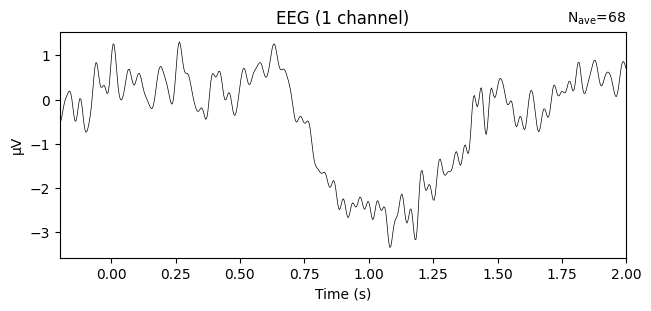

In [5]:
evoked_co = epochs['12','13','14','15','16','17','18','19'].average()
evoked_in = epochs['24','25','26','27','28','29','30','31'].average()
evoked_co.plot(picks=['FCZ']);

Need more than one channel to make topography for eeg. Disabling interactivity.


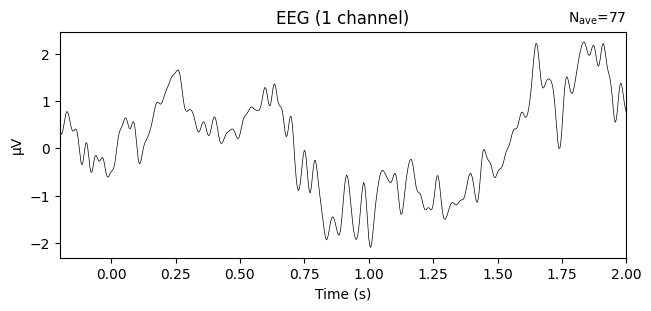

In [6]:
evoked_in.plot(picks=['FCZ']);

# Procesamiento de todos los sujetos

In [4]:
ruta_casa = r"C:\Users\Usuario\OneDrive - Universidad de Medellin\JupyterNotebooks\IAT\EEG"
ruta_oficina = r"C:\Users\jhquiza\Downloads\EEG"

def cargar_eeg(ruta=ruta_oficina):
    rutas_archivos=[]
    Docs_carpeta= os.listdir(ruta)
    for q in range(len(Docs_carpeta)):
        name_doc=Docs_carpeta[q]
        if ".edf" in name_doc:
            ruta = re.sub(r"\s+$", "", ruta, flags=re.UNICODE)
            r1= ruta + "\\" + name_doc
            rutas_archivos.append(r1)
    return rutas_archivos

In [7]:
rutas_archivos = cargar_eeg(ruta_oficina)
log_processing = pd.DataFrame(columns=['Subject', 'Bad channels', 'Total bad channels', 'Bad ICA components', 
                                       'Total bad ICA components', 'Total bad epochs'])
for l in range(len(rutas_archivos)):
    ruta = rutas_archivos[l]
    raw = mne.io.read_raw_edf(ruta, preload=True)
    epochs, bad_channels, ica_bad_components, bad_epochs = Preprocesamiento_REST_ICA_epoch(raw, threshold=0.9)
    epochs.save(ruta[-14:-9] + '_epo.fif', overwrite=True)
    # Guardar en un dataframe los canales malos, los componentes ICA malos y las épocas malas por sujeto
    log_sujeto = pd.DataFrame({'Subject': [ruta[-14:-9]], 'Bad channels': [bad_channels],
                               'Total bad channels': len(bad_channels), 'Bad ICA components': [ica_bad_components],
                                'Total bad ICA components':len(ica_bad_components), 'Total bad epochs': [bad_epochs]})
    log_processing = pd.concat([log_processing, log_sujeto], ignore_index=True)
log_processing.to_csv('log_processing.csv', index=False)


Extracting EDF parameters from C:\Users\jhquiza\Downloads\EEG\21100_IAT2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 987135  =      0.000 ...   482.000 secs...
Fitted sphere radius:         95.0 mm
Origin head coordinates:      0.0 -0.0 40.1 mm
Origin device coordinates:    0.0 -0.0 40.1 mm

Equiv. model fitting -> RV = 0.00349069 %%
mu1 = 0.944696    lambda1 = 0.137201
mu2 = 0.667442    lambda2 = 0.683754
mu3 = -0.266813    lambda3 = -0.010585
Set up EEG sphere model with scalp radius    95.0 mm

Sphere                : origin at (0.0 -0.0 40.1) mm
              radius  : 85.5 mm
grid                  : 5.0 mm
mindist               : 5.0 mm
Exclude               : 30.0 mm

Setting up the sphere...
Surface CM = (   0.0   -0.0   40.1) mm
Surface fits inside a sphere with radius   85.5 mm
Surface extent:
    x =  -85.5 ...   85.5 mm
    y =  -85.5 ...   85.5 mm
    z =  -45.4 ...  125.6 mm
Grid extent:
    x =  -90.0 ...   90.0 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 6759 samples (3.300 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


EEG channel type selected for re-referencing
Applying REST reference.
Applying a custom ('EEG',) reference.
    64 out of 64 channels remain after picking
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 59 components
Fitting ICA took 111.1s.
Using EOG channel: FPZ
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 20480 samples (10.000 s)



...

EEG channel type selected for re-referencing
Applying REST reference.
Applying a custom ('EEG',) reference.
    64 out of 64 channels remain after picking
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 59 components
Fitting ICA took 131.9s.
Using EOG channel: FPZ
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 20480 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.5s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 20480 samples (10.000 s)

Effective window size : 1.000 (s)
Applying ICA to Raw instance
    Transforming to ICA space (59 components)
    Zeroing out 8 ICA components
    Projecting back using 64 PCA components
372 events found on stim channel Status
Event IDs: [  6   7   8   9  12  13  14  15  16  17  18  19  22  23  24  25  26  27
  28  29  30  31  70  72  73  76  78  79  80  81  82  83  87  89  90  91
  94  95 102 103 104 105 108 109 110 111 112 113 114 115 118 119 120 121
 122 123 124 125 126 127]
Filtering r

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Not setting metadata
149 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 149 events and 4507 original time points (prior to decimation) ...
0 bad epochs dropped
Dropped 24 epochs: 0, 5, 6, 23, 25, 26, 27, 48, 49, 51, 52, 84, 88, 89, 106, 107, 121, 122, 123, 124, 131, 132, 140, 144
Canales ruidosos:  ['POZ', 'PO3', 'P1', 'P2']
Componentes oculares:  [0, 15]
Componentes musculares:  [1, 7, 13, 21, 27, 37]
Épocas rechazadas:  24


In [30]:
log_processing

,Subject,Bad channels,Total bad channels,Bad ICA components,Total bad ICA components,Total bad epochs
0,21101,"[PO7, FP1, PO4, P3, AF8, FP2, AF7]",7,"[5, 7, 9, 10, 11, 14, 21, 26]",8,11
1,21122,"[TP8, TP7, T8, FC2]",4,"[15, 10, 17, 20, 27, 29]",6,10
2,23002,"[P1, P9, POZ, T8, PO3, AF7]",6,"[0, 10, 3, 2, 1, 2, 3, 6, 7, 8, 9, 11, 12, 13,...",24,3


# Ver ERP resultantes

Reading c:\Users\Usuario\OneDrive - Universidad de Medellin\JupyterNotebooks\IAT\21101n_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
143 matching events found
No baseline correction applied
0 projection items activated
Using matplotlib as 2D backend.


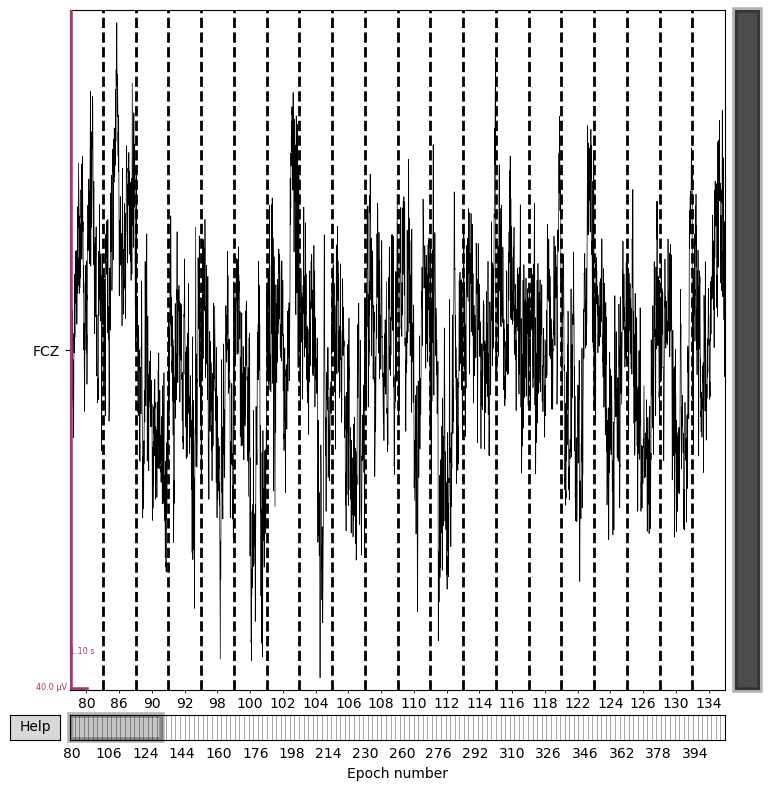

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Attempting to create new mne-python configuration file:
C:\Users\Usuario\.mne\mne-python.json


In [ ]:
erp = mne.read_epochs('21101n_epo.fif')
erp.plot(picks=['FCZ'])

In [3]:
evoked_co = erp['12','13','14','15','16','17','18','19'].average()
evoked_in = erp['24','25','26','27','28','29','30','31'].average()

Need more than one channel to make topography for eeg. Disabling interactivity.


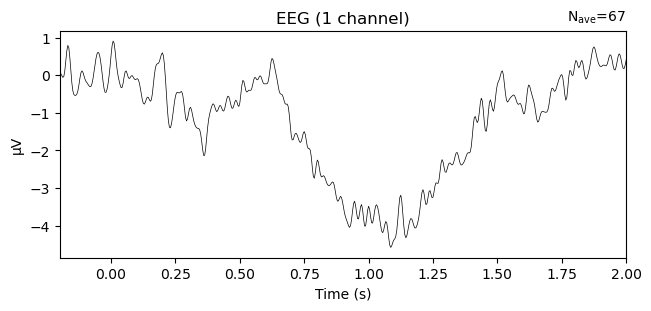

In [4]:
evoked_co.plot(picks=['FCZ'])

Need more than one channel to make topography for eeg. Disabling interactivity.


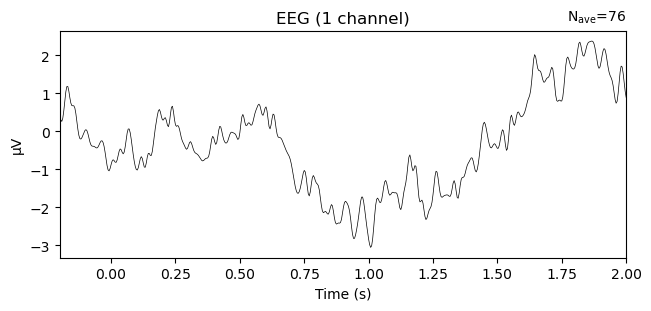

In [5]:
evoked_in.plot(picks=['FCZ'])

Reading c:\Users\Usuario\OneDrive - Universidad de Medellin\JupyterNotebooks\IAT\21122n_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
122 matching events found
No baseline correction applied
0 projection items activated


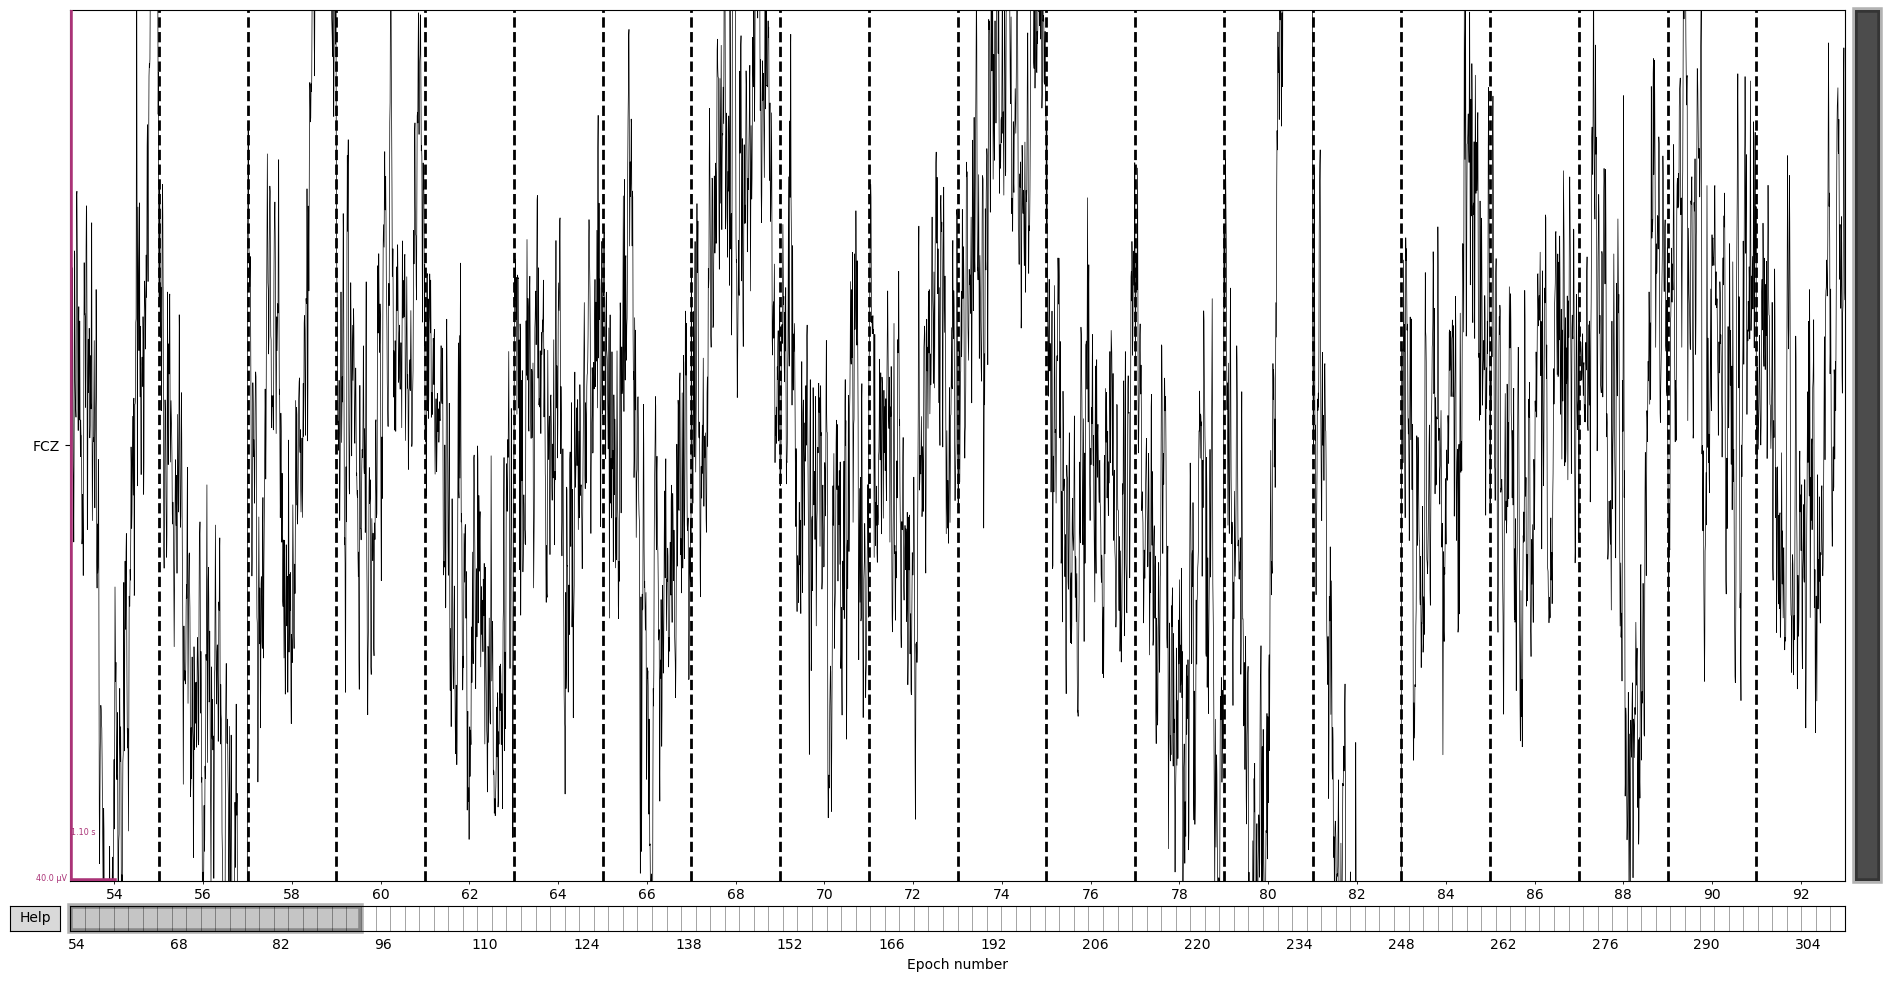

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [ ]:
erp = mne.read_epochs('21122n_epo.fif')
erp.plot(picks=['FCZ'])

In [8]:
evoked_co = erp['12','13','14','15','16','17','18','19'].average()
evoked_in = erp['24','25','26','27','28','29','30','31'].average()

Need more than one channel to make topography for eeg. Disabling interactivity.


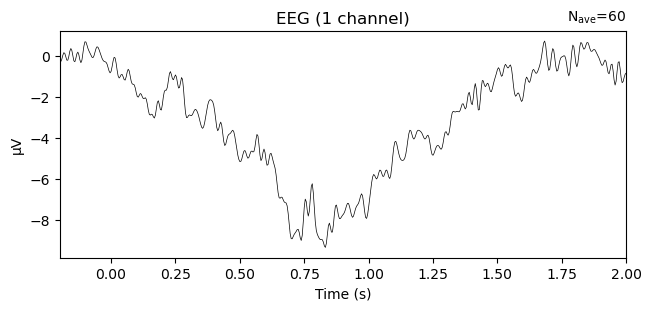

In [9]:
evoked_co.plot(picks=['FCZ'])

Need more than one channel to make topography for eeg. Disabling interactivity.


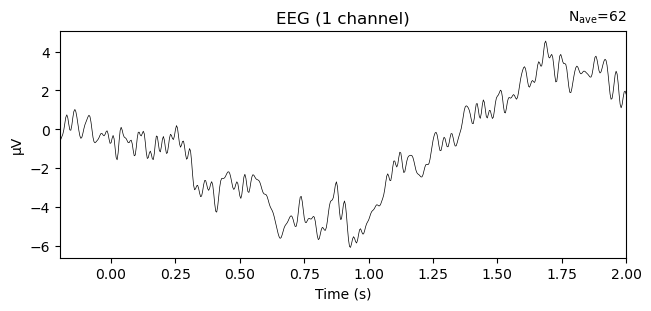

In [10]:
evoked_in.plot(picks=['FCZ'])

Reading c:\Users\Usuario\OneDrive - Universidad de Medellin\JupyterNotebooks\IAT\23002n_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
114 matching events found
No baseline correction applied
0 projection items activated


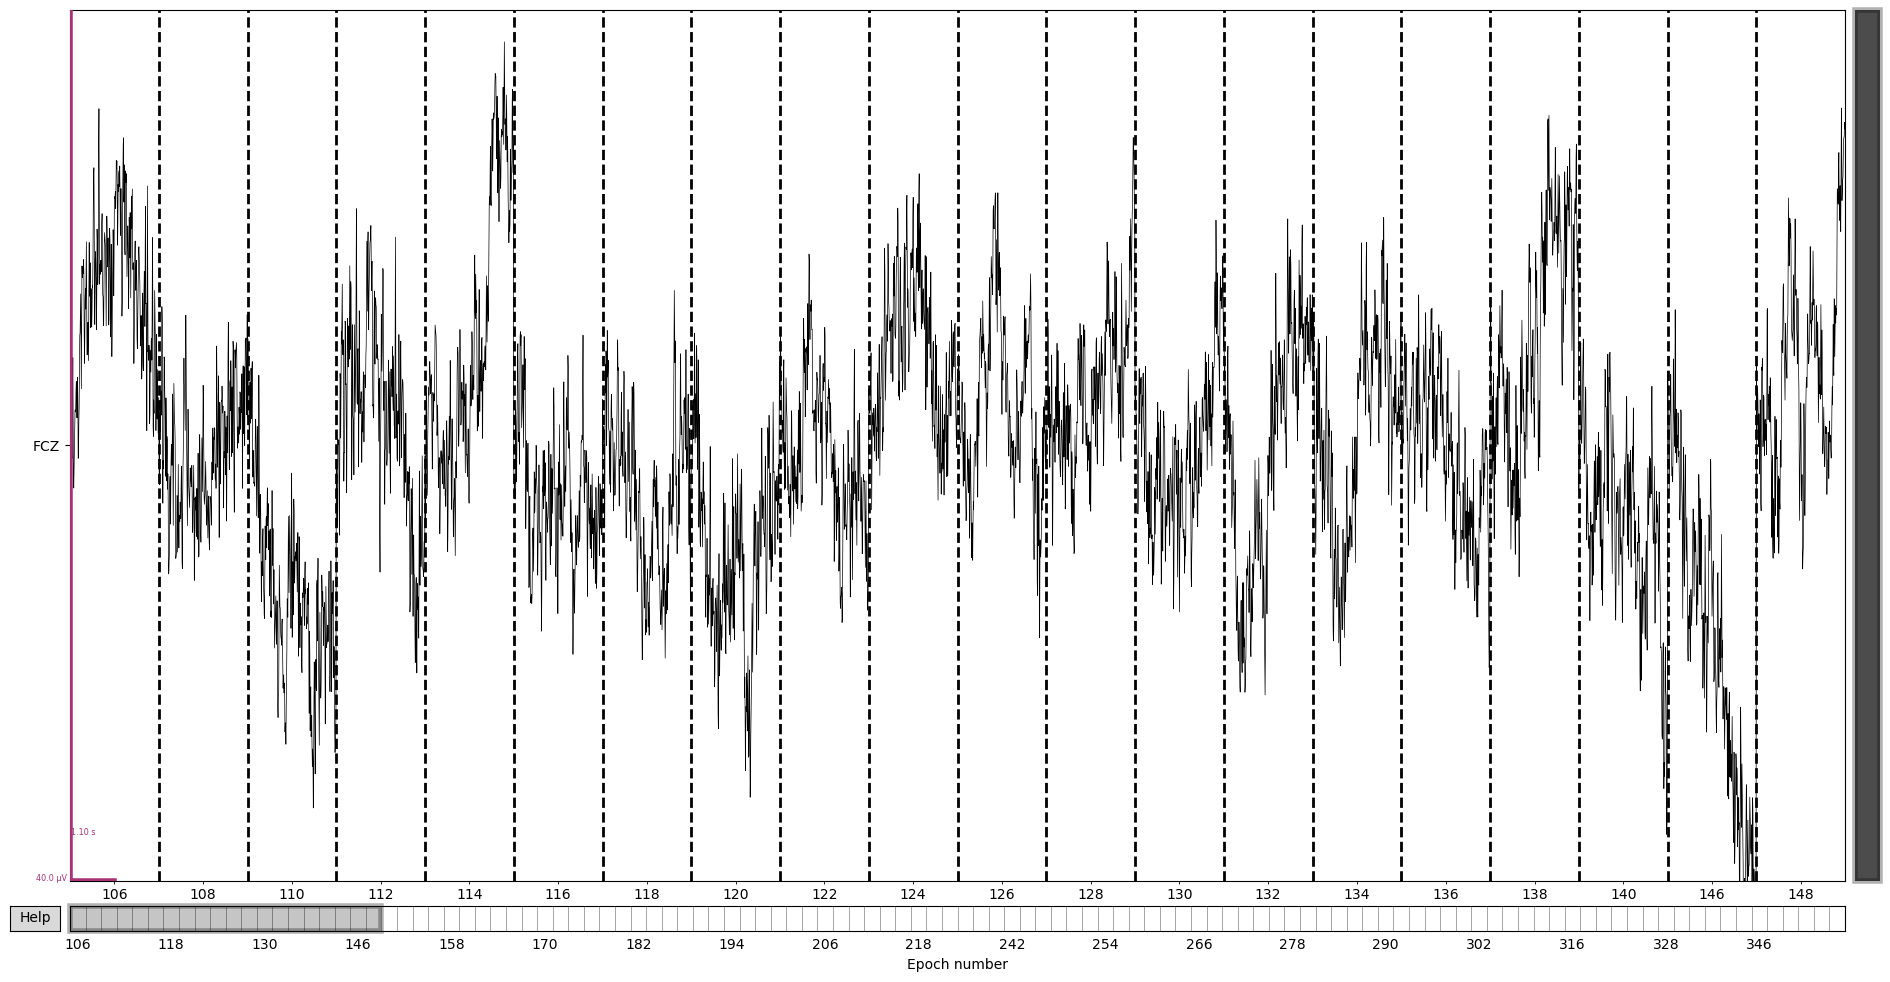

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [ ]:
erp = mne.read_epochs('23002n_epo.fif')
erp.plot(picks=['FCZ'])

Need more than one channel to make topography for eeg. Disabling interactivity.


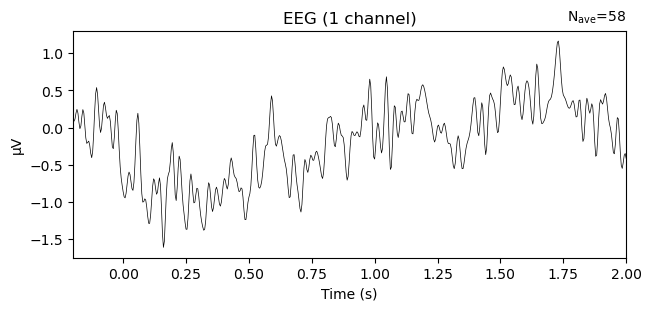

In [12]:
evoked_co = erp['12','13','14','15','16','17','18','19'].average()
evoked_in = erp['24','25','26','27','28','29','30','31'].average()
evoked_co.plot(picks=['FCZ'])

Need more than one channel to make topography for eeg. Disabling interactivity.


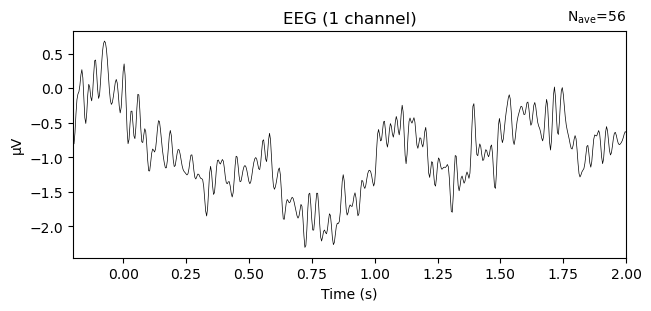

In [13]:
evoked_in.plot(picks=['FCZ'])